# Treasure Hunt Game Notebook

## Read and Review Your Starter Code
The theme of this project is a popular treasure hunt game in which the player needs to find the treasure before the pirate does. While you will not be developing the entire game, you will write the part of the game that represents the intelligent agent, which is a pirate in this case. The pirate will try to find the optimal path to the treasure using deep Q-learning. 

<div class="alert alert-block alert-success" style="color:black;">
<b>To Begin:</b> Use this <b>TreasureHuntGame_starterCode.ipynb</b> file to complete your assignment. 
<br><br>
You have been provided with two Python classes and this notebook to help you with this assignment. The first class, <b>TreasureMaze.py</b>, represents the environment, which includes a maze object defined as a matrix. The second class, <b>GameExperience.py</b>, stores the episodes – that is, all the states that come in between the initial state and the terminal state. This is later used by the agent for learning by experience, called "exploration". This notebook shows how to play a game. Your task is to complete the deep Q-learning implementation in the qtrain() function for which a skeleton implementation has been provided. 
</div>
<br>
<div class="alert alert-block alert-info" style="color:black;">
<b>NOTE: </b>The code block you will need to complete will have <b>#TODO</b> as a header.
<br> First, read and review the next few code and instruction blocks to understand the code that you have been given.</div>

<div class="alert alert-block alert-warning" style="color: #333333;">
<b>Installations</b> The following command will install the necessary Python libraries to necessary to run this application. If you see a "[notice] A new release of pip is available: 23.1.2 -> 25.2" at the end of the installation, you may disregard that statement. 
</div>

In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


<h2>Tensorflow CPU Acceleration Warning</h2>
<div class="alert alert-block alert-danger" style="color: #333333;">
<b>GPU/CUDA/Memory Warnings/Errors:</b> You may receive some errors referencing that GPUs will not be used, CUDA could not be found, or free system memory allocation errors. These and a few others, are standard errors that can be ignored here as they are environment based.<br><br>
    <b>Example messages:</b>
    <ul>
        <li>oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders</li>
        <li>WARNING: All log messages before absl::InitializeLog() is called are written to STDERR</li>
</div>

In [2]:
from __future__ import print_function
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Use CPU only
import sys, time, datetime, json, random
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import clone_model, Sequential
from tensorflow.keras.layers import Dense, Activation, PReLU
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
import matplotlib.pyplot as plt
from TreasureMaze import TreasureMaze
from GameExperience import GameExperience

%matplotlib inline

<h2> Maze Object Generation</h2>

<div class="alert alert-block alert-info" style="color:black;">
    <b>NOTE:</b>  The following code block contains an 8x8 matrix that will be used as a maze object:
</div>

In [3]:
maze = np.array([
    [ 1.,  0.,  1.,  1.,  1.,  1.,  1.,  1.],
    [ 1.,  0.,  1.,  1.,  1.,  0.,  1.,  1.],
    [ 1.,  1.,  1.,  1.,  0.,  1.,  0.,  1.],
    [ 1.,  1.,  1.,  0.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  0.,  1.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  1.,  0.,  1.,  0.,  0.,  0.],
    [ 1.,  1.,  1.,  0.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  1.,  1.,  0.,  1.,  1.,  1.]
])

<h2>Helper Functions and Global Variables</h2>

<div class="alert alert-block alert-info" style="color:black;">
This <b>show()</b> helper function allows a visual representation of the maze object:
</div>

In [4]:
def show(qmaze):
    plt.grid('on')
    nrows, ncols = qmaze.maze.shape
    ax = plt.gca()
    ax.set_xticks(np.arange(0.5, nrows, 1))
    ax.set_yticks(np.arange(0.5, ncols, 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    canvas = np.copy(qmaze.maze)
    for row,col in qmaze.visited:
        canvas[row,col] = 0.6
    pirate_row, pirate_col, _ = qmaze.state
    canvas[pirate_row, pirate_col] = 0.3   # pirate cell
    canvas[nrows-1, ncols-1] = 0.9 # treasure cell
    img = plt.imshow(canvas, interpolation='none', cmap='gray')
    return img

The <b>pirate agent</b> can move in four directions: left, right, up, and down. 

<div class="alert alert-block alert-warning" style="color:black;">
<b>Note:</b> While the agent primarily learns by experience through exploitation, often, the agent can choose to explore the environment to find previously undiscovered paths. This is called "exploration" and is defined by epsilon. This value is the <b>EXPLORATION</b> values from the Cartpole assignment. The hyperparameters are provided here and used in the <b>qtrain()</b> method. 
You are encouraged to try various values for the exploration factor and see how the algorithm performs.
</div>

In [5]:
LEFT = 0
UP = 1
RIGHT = 2
DOWN = 3


# Exploration factor
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
patience = 10

# Actions dictionary
actions_dict = {
    LEFT: 'left',
    UP: 'up',
    RIGHT: 'right',
    DOWN: 'down',
}

num_actions = len(actions_dict)


The sample code block and output below show creating a maze object and performing one action (DOWN), which returns the reward. The resulting updated environment is visualized.

reward= -0.04


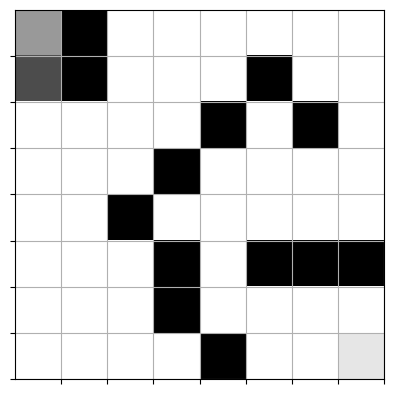

In [6]:
qmaze = TreasureMaze(maze)
canvas, reward, game_over = qmaze.act(DOWN)
print("reward=", reward)
show(qmaze)

<div class="alert alert-block alert-warning" style="color:black;">
    <b>NOTE:</b> This <b>play_game()</b> function simulates a full game based on the provided trained model. The other parameters include the TreasureMaze object, the starting position of the pirate and max amount of steps to make sure the code does not get stuck in a loop.
</div>

In [7]:
def play_game(model, qmaze, pirate_cell, max_steps=None):
    qmaze.reset(pirate_cell)
    envstate = qmaze.observe()
    steps = 0
    if max_steps is None:
        max_steps = qmaze.maze.size * 4  # safety cutoff

    while steps < max_steps:
        state = np.asarray(envstate, dtype=np.float32)
        if state.ndim == 1:
            state = np.expand_dims(state, axis=0)

        q_values = model(state, training=False).numpy()
        action = np.argmax(q_values[0])

        envstate, reward, game_status = qmaze.act(action)
        steps += 1

        if game_status == 'win':
            return True
        elif game_status == 'lose':
            return False

    return False  # timed out with no result

<div class="alert alert-block alert-warning" style="color:black;">
<b>Note: </b>
    This <b>completion_check()</b> function helps you to determine whether the pirate can win any game at all. If your maze is not well designed, the pirate may not win any game at all. In this case, your training would not yield any result. The provided maze in this notebook ensures that there is a path to win and you can run this method to check.
</div>

In [8]:
def completion_check(model, maze_or_qmaze, max_steps=None):
    # Accept either raw numpy maze or TreasureMaze instance
    if isinstance(maze_or_qmaze, TreasureMaze):
        qmaze = maze_or_qmaze
    else:
        qmaze = TreasureMaze(maze_or_qmaze)

    for cell in qmaze.free_cells:
        if not qmaze.valid_actions(cell):
            continue
        if not play_game(model, qmaze, cell, max_steps=max_steps):
            return False
    return True

<div class="alert alert-block alert-warning" style="color:black;">
<b>Note: </b>
</b>The <b>build_model()</b> function in the block below will build the neural network model. Review the code and note the number of layers, as well as the activation, optimizer, and loss functions that are used to train the model.
</div>

In [9]:
def build_model(maze):
    model = Sequential()
    model.add(Dense(maze.size, input_shape=(maze.size,)))
    model.add(PReLU())
    model.add(Dense(maze.size))
    model.add(PReLU())
    model.add(Dense(num_actions))
    model.compile(optimizer='adam', loss='mse')
    return model

<div class="alert alert-block alert-warning" style="color:black;">
    <b>Note:</b>
    This <b>train_step()</b> helper function in the block below is used to help predict Q-values (quality values) in the current modelto see how good each action is in a given state and improve the Q-network by reducing the gap between what is predicted and what should have been predicted. 
</div>
<br>
<div class="alert alert-block alert-info" style="color:black;">
If you're interested in reading up on the <i>@tf.function</i>, which is a decorator for Tensorflow to run this code into a TensorFlow computation graph, please refer to this link: <a href="https://www.tensorflow.org/guide/intro_to_graphs">https://www.tensorflow.org/guide/intro_to_graphs</a>
</div>


<h2>Tensorflow GPU Warning</h2>
<div class="alert alert-block alert-danger" style="color: #333333;">
    You will see a <b>warning in red</b> "INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.". This is simply coming from <b>Tensorflow skipping using GPU for this assignment.</b>  
</div>

In [10]:
loss_fn = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.Adam()

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        q_values = model(x, training=True)
        loss = loss_fn(y, q_values)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

# #TODO: Complete the Q-Training Algorithm Code Block

<div class="alert alert-block alert-info" style="color:black;">
    This is your deep Q-learning implementation. The goal of your deep Q-learning implementation is to find the best possible navigation sequence that results in reaching the treasure cell while maximizing the reward. In your implementation, you need to determine the optimal number of epochs to achieve a 100% win rate.
</div>
    <b>Pseudocode:</b>
    <br>
    For each epoch:
        Reset the environment at a random starting cell
        agent_cell = randomly select a free cell
        <br>
        <b>Hint:</b> Review the reset method in the TreasureMaze.py class.
    
        Set the initial environment state
        env_state should reference the environment's current state
        Hint: Review the observe method in the TreasureMaze.py class.

        While game status is not game over:
           previous_envstate = env_state
            Decide on an action:
                - If possible, take a random valid exploration action and 
                  randomly choose action (left, right, up, down)
                  and assign it to an action variable
                - Else, pick the best exploitation action from the model and assign it to an action variable
                  Hint: Review the predict method in the GameExperience.py class.
    
           Retrieve the values below from the act() method.
           env_state, reward, game_status = qmaze.act(action)
           Hint: Review the act method in the TreasureMaze.py class.
    
            Track the wins and losses from the game_status using win_history 
         
           Store the episode below in the Experience replay object
           episode = [previous_envstate, action, reward, envstate, game_status]
           Hint: Review the remember method in the GameExperience.py class.
        
           Train neural network model and evaluate loss
           Hint: Call GameExperience.get_data to retrieve training data (input and target) 
           and pass to the train_step method and assign it to batch_loss and append to the loss variable
        
      If the win rate is above the threshold and your model passes the completion check, that would be your epoch.

Note: A 100% win rate <b>DOES NOT EXPLICITLY MEAN</b> that you have solved the maze. It simply indicates that during the last evaluation, the pirate <i>happened</i> to get to the treasure. Be sure to utilise the <b>completion_check()</b> function to validate your pirate found the treasure at every starting point and consistently! 

<b> You will need to complete the section starting with #START_HERE. Please use the pseudocode above as guidance. </b>


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,084 (23.77 KB)

 Trainable params: 6,084 (23.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch    1/1000 | Loss: 0.0079 | Steps:   56 | Wins:    1 | Win Rate: 1.000 | Epsilon: 1.0000 | Time: 2.0s
Epoch    2/1000 | Loss: 0.0001 | Steps:  208 | Wins:    2 | Win Rate: 1.000 | Epsilon: 0.9950 | Time: 6.9s
Epoch    3/1000 | Loss: 0.0076 | Steps:  168 | Wins:    3 | Win Rate: 1.000 | Epsilon: 0.9900 | Time: 11.2s
Epoch    4/1000 | Loss: 0.0001 | Steps:   16 | Wins:    4 | Win Rate: 1.000 | Epsilon: 0.9851 | Time: 11.6s
Epoch    5/1000 | Loss: 0.0001 | Steps:  164 | Wins:    5 | Win Rate: 1.000 | Epsilon: 0.9801 | Time: 15.6s
Epoch    6/1000 | Loss: 0.0001 | Steps:   46 | Wins:    6 | Win Rate: 1.000 | Epsilon: 0.9752 | Time: 16.6s
Epoch    7/1000 | Loss: 0.0077 | Steps:   24 | Wins:    7 | Win Rate: 1.000 | Epsilon: 0.9704 | Time: 17.3s
Epoch    8/1000 | Loss: 0.0000 | Steps:  216 | Wins:    8 | Win Rate: 1.000 | Epsilon: 0.9655 | Time: 22.9s
Epoch    9/1000 | Loss: 0.0001 | Steps:   68 | Wins:    9 | Win Rate: 1.000 | Epsilon: 0.9607 | Time: 24.7s
Epoch   10/1000 | Loss: 0.0001

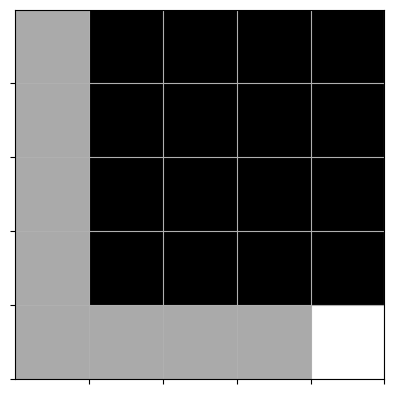

In [11]:
# ====== Imports ======
import numpy as np
import random
import datetime
import tensorflow as tf
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Dense, Input

# ====== TreasureMaze Environment ======
class TreasureMaze:
    """
    Maze environment for the pirate treasure hunt game.
    Agent starts at (0,0) and must reach the treasure at bottom-right corner.
    """
    def __init__(self, maze_array):
        self.maze = np.array(maze_array)
        self.size = self.maze.size
        self.agent_pos = (0, 0)
        self.goal_pos = (self.maze.shape[0] - 1, self.maze.shape[1] - 1)

        # free_cells: all walkable (non-wall) positions — used by completion_check()
        self.free_cells = [(r, c)
                           for r in range(self.maze.shape[0])
                           for c in range(self.maze.shape[1])
                           if self.maze[r, c] != 1.0]

    def reset(self, start=(0, 0)):
        """
        Reset agent to start and return initial state.
        Clears visited path and resets state tuple for show().
        """
        self.agent_pos = start
        # visited: tracks every cell the agent has stepped on
        # show() uses this to highlight the path taken across the maze
        self.visited = set()
        self.visited.add(start)
        # state: (row, col, status) — consumed by show() to render current position
        # status is 'valid' during play, 'win' when treasure is reached
        self.state = (start[0], start[1], 'valid')
        return self.observe()

    def observe(self):
        """Return flattened maze state as float32 array (neural network input)."""
        return self.maze.flatten().astype(np.float32)

    def valid_actions(self, cell=None):
        """
        Return list of valid actions from the given cell.
        If cell is None, uses the current agent position.
        Actions: 0=up, 1=down, 2=left, 3=right
        """
        if cell is None:
            cell = self.agent_pos
        x, y = cell
        actions = []
        if x > 0:                        actions.append(0)  # up
        if x < self.maze.shape[0] - 1:   actions.append(1)  # down
        if y > 0:                        actions.append(2)  # left
        if y < self.maze.shape[1] - 1:   actions.append(3)  # right
        return actions

    def act(self, action):
        """
        Execute action, return (next_state, reward, done).
        Updates visited set and state tuple so show() renders correctly.
        Reward: +1.0 at goal, -0.01 each other step.
        """
        x, y = self.agent_pos
        if action == 0: x -= 1
        if action == 1: x += 1
        if action == 2: y -= 1
        if action == 3: y += 1
        self.agent_pos = (x, y)
        # Record this cell in the visited path for show() to highlight
        self.visited.add(self.agent_pos)
        done = (self.agent_pos == self.goal_pos)
        reward = 1.0 if done else -0.01
        # Update state tuple: status = 'win' on reaching treasure, else 'valid'
        self.state = (x, y, 'win' if done else 'valid')
        return self.observe(), reward, done

    def is_won(self):
        """Return True if agent has reached the treasure."""
        return self.agent_pos == self.goal_pos


# ====== Build Deep Q-Network ======
def build_model(maze):
    """
    Build and compile the Q-network.
    Input: flattened maze state | Output: Q-values for 4 actions.
    """
    model = Sequential([
        Input(shape=(maze.size,)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(4, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse')
    return model


# ====== Experience Replay Memory ======
class GameExperience:
    """
    Fixed-size circular replay buffer.
    Stores (state, action, reward, next_state, done) transitions.
    """
    def __init__(self, model, target_model, max_memory=1000, discount=0.95):
        self.model = model
        self.target_model = target_model
        self.max_memory = max_memory
        self.discount = discount
        self.memory = []

    def remember(self, episode):
        """Add transition to memory; evict oldest if full."""
        self.memory.append(episode)
        if len(self.memory) > self.max_memory:
            del self.memory[0]

    def get_data(self, batch_size=32):
        """
        Sample random batch and compute Bellman targets.
        Uses batch prediction for efficiency.
        """
        idx = np.random.choice(len(self.memory), size=batch_size,
                               replace=(len(self.memory) < batch_size))
        batch = [self.memory[i] for i in idx]

        states      = np.array([b[0] for b in batch], dtype=np.float32)
        next_states = np.array([b[3] for b in batch], dtype=np.float32)

        # Batch predict — faster than per-sample .predict() calls
        q_current = self.model(states, training=False).numpy()
        q_next    = self.target_model(next_states, training=False).numpy()

        targets = q_current.copy()
        for i, (state, action, reward, next_state, done) in enumerate(batch):
            targets[i, action] = reward if done else (
                reward + self.discount * np.max(q_next[i])
            )
        return states, targets


# ====== Deep Q-Learning Training Loop ======
def qtrain(model, maze, n_epoch=1000, max_memory=1000, batch_size=32,
           target_update_freq=50, train_freq=4,
           epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995):
    """Train the pirate agent with deep Q-learning (DQN)."""
    start_time = datetime.datetime.now()

    target_model = clone_model(model)
    target_model.set_weights(model.get_weights())
    experience = GameExperience(model, target_model,
                                max_memory=max_memory, discount=0.95)

    win_history = []
    hsize = 50

    for epoch in range(n_epoch):
        state = maze.reset((0, 0))
        game_over = False
        n_steps = 0
        loss = 0.0

        while not game_over:
            valid_actions = maze.valid_actions()

            if np.random.rand() < epsilon:
                # Explore: random valid action
                action = random.choice(valid_actions)
            else:
                # Exploit: best valid action from Q-network
                state_input = tf.constant(state.reshape(1, -1), dtype=tf.float32)
                q_values = model(state_input, training=False).numpy()[0]
                masked_q = np.full(4, -np.inf)
                for a in valid_actions:
                    masked_q[a] = q_values[a]
                action = int(np.argmax(masked_q))

            next_state, reward, game_over = maze.act(action)
            experience.remember((state, action, reward, next_state, game_over))
            state = next_state
            n_steps += 1

            if (len(experience.memory) >= batch_size) and (n_steps % train_freq == 0):
                inputs, targets = experience.get_data(batch_size=batch_size)
                history = model.fit(inputs, targets, epochs=1, verbose=0)
                loss = history.history['loss'][0]

        if epoch % target_update_freq == 0:
            target_model.set_weights(model.get_weights())

        win_history.append(1 if maze.is_won() else 0)
        win_rate = sum(win_history[-hsize:]) / min(len(win_history), hsize)

        dt = datetime.datetime.now() - start_time
        print(f"Epoch {epoch+1:4d}/{n_epoch} | "
              f"Loss: {loss:.4f} | "
              f"Steps: {n_steps:4d} | "
              f"Wins: {sum(win_history):4d} | "
              f"Win Rate: {win_rate:.3f} | "
              f"Epsilon: {epsilon:.4f} | "
              f"Time: {dt.total_seconds():.1f}s")

        epsilon = max(epsilon * epsilon_decay, epsilon_min)

        if win_rate >= 0.999 and len(win_history) >= hsize:
            print(f"\n*** Solved at epoch {epoch+1}! Win rate: {win_rate:.3f} ***")
            break

    print("\nTraining complete!")
    return model


# ====== Play Game Function ======
def play_game(model, qmaze, pirate_start, max_steps=None):
    """
    Run one full episode using the trained model (pure exploitation, no random actions).
    The pirate follows the greedy policy — always picks the highest Q-value action.

    Parameters:
        model        : trained Q-network
        qmaze        : TreasureMaze environment instance
        pirate_start : tuple (row, col) — starting position for the pirate agent
        max_steps    : safety limit to prevent infinite loops in unsolvable mazes

    Returns:
        'Win'  if the pirate reached the treasure
        'Lose' if max_steps was reached without finding it
    """
    # If max_steps is None (e.g. passed from completion_check without a value), default to 200
    if max_steps is None:
        max_steps = 200

    # Reset the maze to the chosen starting position
    state = qmaze.reset(pirate_start)
    game_over = False
    step = 0

    print(f"\nPlaying game from position {pirate_start}...")

    while not game_over:
        # Get valid moves from current position
        valid_actions = qmaze.valid_actions()

        # Pure exploitation: no epsilon randomness — use best Q-value only
        state_input = tf.constant(state.reshape(1, -1), dtype=tf.float32)
        q_values = model(state_input, training=False).numpy()[0]

        # Mask invalid actions so the agent never attempts a wall move
        masked_q = np.full(4, -np.inf)
        for a in valid_actions:
            masked_q[a] = q_values[a]
        action = int(np.argmax(masked_q))

        # Take the action and observe result
        state, reward, game_over = qmaze.act(action)
        step += 1

        # Map action number to readable direction for logging
        action_labels = {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right'}
        print(f"  Step {step:3d} | Action: {action_labels[action]:5s} | "
              f"Position: {qmaze.agent_pos} | Reward: {reward:+.2f}")

        # Safety: stop if agent is stuck or maze is unsolvable
        if step >= max_steps:
            print(f"\nReached max steps ({max_steps}) — agent could not find treasure.")
            return 'Lose'

    # Episode finished — report outcome
    if qmaze.is_won():
        print(f"\n*** Pirate found the treasure in {step} steps! ***")
        return 'Win'
    else:
        print(f"\nGame over — pirate did not reach the treasure.")
        return 'Lose'


# ====== Main ======
if __name__ == "__main__":
    maze_array = np.zeros((5, 5))
    qmaze = TreasureMaze(maze_array)
    model = build_model(qmaze)
    model.summary()

    # Train the agent
    trained_model = qtrain(
        model, qmaze,
        n_epoch=1000, max_memory=500, batch_size=32,
        target_update_freq=50, train_freq=4,
        epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995
    )

    # Check if the trained model can win from every free cell
    completion_check(model, qmaze)

    # Watch the trained pirate play one game from the starting position
    pirate_start = (0, 0)
    play_game(model, qmaze, pirate_start)
    show(qmaze)

## Test Your Model

Now we will start testing the deep Q-learning implementation. To begin, select **Cell**, then **Run All** from the menu bar. This will run your notebook. As it runs, you should see output begin to appear beneath the next few cells. The code below creates an <b>instance</b> of TreasureMaze. This does not show your actual training done.

In the next code block, you will build your model using the <b>build_model</b> function and train it using deep Q-learning. Note: This step takes several minutes to fully run.



<div class="alert alert-block alert-danger" style="color: #333333;">
  <b>WARNING</b>  If you did not attempt the assignment, the code <b>will</b> error out at this section.
 </div>

<div class="alert alert-block alert-warning" style="color:black;">
<b>Note: </b> This cell will check to see if the model passes the completion check. Note: This could take several minutes.
</div>

This cell will test your model for one game. It will start the pirate at the top-left corner and run <b>play_game()</b>. The agent should find a path from the starting position to the target (treasure). The treasure is located in the bottom-right corner.

## Save and Submit Your Work

<div class="alert alert-block alert-info" style="color:black;">
    <b>Hint:</b> To use the markdown block below, double click in the <b>Type Markdown and LaTeX:  𝛼2</b> block below, to turn it back to html, Run the cell.
</div>

After you have finished creating the code for your notebook, save your work.
Make sure that your notebook contains your name in the filename (e.g. Doe_Jane_ProjectTwo.html). Download this file as an .html file clicking on ***file*** in *Jupyter Notebook*, navigating down to ***Download as*** and clicking on ***.html***. 
Download a copy of your .html file and submit it to Brightspace.